In [14]:
import pandas as pd
import autoslo.utils.paths as pu
import os


strategy_results_dir = os.path.join(pu.get_data_path(), 'strategy_runs') 

dfs = []
for workload_dir in os.listdir(strategy_results_dir):
    workload_path = os.path.join(strategy_results_dir, workload_dir)
    if not os.path.isdir(workload_path):
        continue

    for slo_dir in os.listdir(workload_path):
        slo_path = os.path.join(workload_path, slo_dir)
        if not os.path.isdir(slo_path):
            continue

        summary_csv_path = os.path.join(slo_path, 'slo_vs_cost_summary.csv')
        if not os.path.isfile(summary_csv_path):
            continue

        df = pd.read_csv(summary_csv_path)
        df['workload'] = workload_dir
        df['slo'] = slo_dir
        dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)

In [15]:
all_df

,strategy_name,frac_days_met_slo,total_cost,workload,slo
0,StratExactFutureFullPerfSingle,1.000000,45.583333,weekly_peak,300s_slo
1,StratExactFuturePredPerfSingle,1.000000,60.596667,weekly_peak,300s_slo
2,StratHistUniformFullPerfSingle1,0.714286,49.066667,weekly_peak,300s_slo
3,StratHistUniformFullPerfSingle14,1.000000,60.596667,weekly_peak,300s_slo
4,StratHistUniformFullPerfSingle7,1.000000,60.596667,weekly_peak,300s_slo
...,...,...,...,...,...
355,StratHistUniformFullPerfSingle14,1.000000,114.833333,growth_h_base,60s_slo
356,StratHistUniformFullPerfSingle7,1.000000,114.833333,growth_h_base,60s_slo
357,StratHistUniformObsPerfSingle1,1.000000,114.833333,growth_h_base,60s_slo
358,StratHistUniformObsPerfSingle14,1.000000,114.833333,growth_h_base,60s_slo


In [ ]:
slo_threshold = 0.05

# Assert that there is no combination of workoad  and slo for which StratExactFutureFullPerfSingle
# is dominated by another strategy in terms of frac_days_met_slo

for (workload, slo), group in all_df.groupby(['workload', 'slo']):
    strat_exact = group[group['strategy_name'] == 'StratExactFutureFullPerfSingle'].iloc[0]
    for _, row in group.iterrows():
        if row['strategy_name'] == 'StratExactFutureFullPerfSingle':
            continue
        if (row['frac_days_met_slo'] > strat_exact['frac_days_met_slo']):
            print(f"Domination found for workload {workload} and slo {slo}:")
            print(f"\tStratExactFutureFullPerfSingle: frac_days_met_slo={strat_exact['frac_days_met_slo']}, total_cost={strat_exact['total_cost']}")
            print(f"\t{row['strategy_name']}: frac_days_met_slo={row['frac_days_met_slo']}, total_cost={row['total_cost']}")
            assert False, "Domination detected!"     

In [21]:
# Create a dataframe where each row is a combination of workload and slo, and columns names
# Are the different strategies. The values are the frac_days_met_slo.

pivot_df = all_df.pivot_table(
    index=['workload', 'slo'],
    columns='strategy_name',
    values='frac_days_met_slo'
).reset_index()


# For each column of the df, count the rows in which that column has the (possibly tied) maximum value across all strategy columns.
strategy_columns = [col for col in pivot_df.columns if col.startswith('Strat')]
for strategy in strategy_columns:
    count = (pivot_df[strategy] == pivot_df[strategy_columns].max(axis=1)).sum()
    print(f"{strategy}: {count} / {len(pivot_df)}")

StratExactFutureFullPerfSingle: 45 / 45
StratExactFuturePredPerfSingle: 28 / 45
StratHistUniformFullPerfSingle1: 25 / 45
StratHistUniformFullPerfSingle14: 32 / 45
StratHistUniformFullPerfSingle7: 32 / 45
StratHistUniformObsPerfSingle1: 26 / 45
StratHistUniformObsPerfSingle14: 44 / 45
StratHistUniformObsPerfSingle7: 44 / 45


In [8]:
df1 = pd.read_parquet("/home/markakis/chunkbench/data/strategy_runs/weekly_random/60s_slo/StratExactFutureFullPerfSingle.parquet")
df1

,strategy_name,workload_name,num_training_days,day_idx,latency_slo_s,slo_violation_rate_threshold,blueprint_name,query_router_name,model_training_run_id,num_slo_violations,num_total_queries,slo_violation_rate,total_cost,total_routing_time_s
0,StratExactFutureFullPerfSingle,weekly_random,14,14,60,0.05,single_32,RFixed(fixed_cluster_name='cluster_32'),1765336099_930,9,349,0.025788,11.090000,0.0
1,StratExactFutureFullPerfSingle,weekly_random,14,15,60,0.05,single_32,RFixed(fixed_cluster_name='cluster_32'),1765336099_930,9,349,0.025788,11.090000,0.0
2,StratExactFutureFullPerfSingle,weekly_random,14,16,60,0.05,single_16,RFixed(fixed_cluster_name='cluster_16'),1765336099_930,2,71,0.028169,3.943333,0.0
3,StratExactFutureFullPerfSingle,weekly_random,14,17,60,0.05,single_32,RFixed(fixed_cluster_name='cluster_32'),1765336099_930,9,349,0.025788,11.090000,0.0
4,StratExactFutureFullPerfSingle,weekly_random,14,18,60,0.05,single_32,RFixed(fixed_cluster_name='cluster_32'),1765336099_930,2,125,0.016000,9.360000,0.0
5,StratExactFutureFullPerfSingle,weekly_random,14,19,60,0.05,single_32,RFixed(fixed_cluster_name='cluster_32'),1765336099_930,0,25,0.000000,5.000000,0.0
6,StratExactFutureFullPerfSingle,weekly_random,14,20,60,0.05,single_32,RFixed(fixed_cluster_name='cluster_32'),1765336099_930,0,25,0.000000,5.000000,0.0
7,StratExactFutureFullPerfSingle,weekly_random,14,21,60,0.05,single_16,RFixed(fixed_cluster_name='cluster_16'),1765336099_930,2,71,0.028169,3.943333,0.0
8,StratExactFutureFullPerfSingle,weekly_random,14,22,60,0.05,single_32,RFixed(fixed_cluster_name='cluster_32'),1765336099_930,2,125,0.016000,9.360000,0.0
9,StratExactFutureFullPerfSingle,weekly_random,14,23,60,0.05,single_32,RFixed(fixed_cluster_name='cluster_32'),1765336099_930,2,125,0.016000,9.360000,0.0


In [9]:
df2 = pd.read_parquet("/home/markakis/chunkbench/data/strategy_runs/weekly_random/60s_slo/StratHistUniformFullPerfSingle1.parquet")
df2

,strategy_name,workload_name,num_training_days,day_idx,latency_slo_s,slo_violation_rate_threshold,blueprint_name,query_router_name,model_training_run_id,num_slo_violations,num_total_queries,slo_violation_rate,total_cost,total_routing_time_s
0,StratHistUniformFullPerfSingle1,weekly_random,14,14,60,0.05,single_32,RFixed(fixed_cluster_name='cluster_32'),1765336099_930,9,349,0.025788,11.090000,0.0
1,StratHistUniformFullPerfSingle1,weekly_random,14,15,60,0.05,single_32,RFixed(fixed_cluster_name='cluster_32'),1765336099_930,9,349,0.025788,11.090000,0.0
2,StratHistUniformFullPerfSingle1,weekly_random,14,16,60,0.05,single_32,RFixed(fixed_cluster_name='cluster_32'),1765336099_930,1,71,0.014085,7.813333,0.0
3,StratHistUniformFullPerfSingle1,weekly_random,14,17,60,0.05,single_16,RFixed(fixed_cluster_name='cluster_16'),1765336099_930,60,349,0.171920,5.845000,0.0
4,StratHistUniformFullPerfSingle1,weekly_random,14,18,60,0.05,single_32,RFixed(fixed_cluster_name='cluster_32'),1765336099_930,2,125,0.016000,9.360000,0.0
5,StratHistUniformFullPerfSingle1,weekly_random,14,19,60,0.05,single_32,RFixed(fixed_cluster_name='cluster_32'),1765336099_930,0,25,0.000000,5.000000,0.0
6,StratHistUniformFullPerfSingle1,weekly_random,14,20,60,0.05,single_32,RFixed(fixed_cluster_name='cluster_32'),1765336099_930,0,25,0.000000,5.000000,0.0
7,StratHistUniformFullPerfSingle1,weekly_random,14,21,60,0.05,single_32,RFixed(fixed_cluster_name='cluster_32'),1765336099_930,1,71,0.014085,7.813333,0.0
8,StratHistUniformFullPerfSingle1,weekly_random,14,22,60,0.05,single_16,RFixed(fixed_cluster_name='cluster_16'),1765336099_930,10,125,0.080000,5.100000,0.0
9,StratHistUniformFullPerfSingle1,weekly_random,14,23,60,0.05,single_32,RFixed(fixed_cluster_name='cluster_32'),1765336099_930,2,125,0.016000,9.360000,0.0


In [10]:
df1['slo_violation_rate'].mean(), df2['slo_violation_rate'].mean()

(np.float64(0.015264423215510834), np.float64(0.028261765435016985))

In [11]:
df1['total_cost'].mean(), df2['total_cost'].mean()

(np.float64(7.711190476190476), np.float64(7.585119047619047))

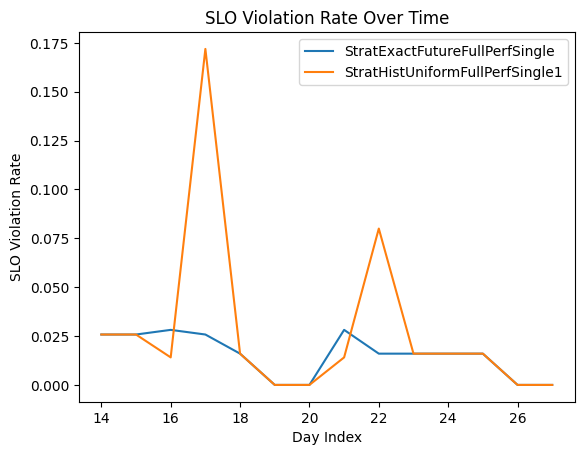

In [12]:
# Plot the slo_violation rate as a timeseries over day_idx for both strategies
import matplotlib.pyplot as plt
plt.plot(df1['day_idx'], df1['slo_violation_rate'], label='StratExactFutureFullPerfSingle')
plt.plot(df2['day_idx'], df2['slo_violation_rate'], label='StratHistUniformFullPerfSingle1')
plt.xlabel('Day Index')
plt.ylabel('SLO Violation Rate')
plt.title('SLO Violation Rate Over Time')
plt.legend()
plt.show()

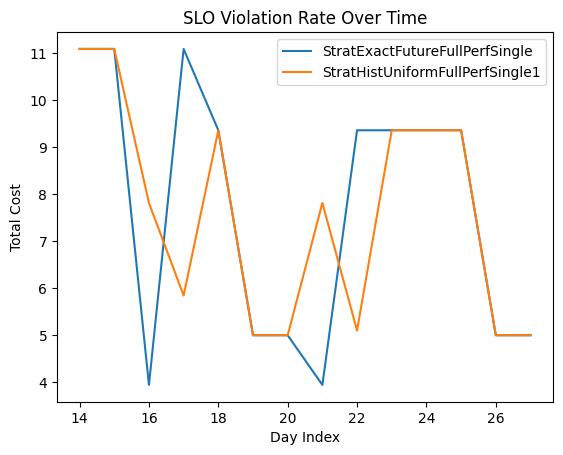

In [13]:
# Plot the cost as a timeseries over day_idx for both strategies
import matplotlib.pyplot as plt
plt.plot(df1['day_idx'], df1['total_cost'], label='StratExactFutureFullPerfSingle')
plt.plot(df2['day_idx'], df2['total_cost'], label='StratHistUniformFullPerfSingle1')
plt.xlabel('Day Index')
plt.ylabel('Total Cost')
plt.title('SLO Violation Rate Over Time')
plt.legend()
plt.show()